In [1]:
from google.colab import files
files.upload()

Saving ppppppppppppppppp.jpg to ppppppppppppppppp.jpg


{'ppppppppppppppppp.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x10\x12\x12\x10\x12\x12\x12\x10\x10\x12\x10\x10\x0f\x10\x10\x10\x10\x10\x0f\x0f\x10\x0f\x10\x15\x12\x16\x16\x15\x12\x15\x15\x18\x1d( \x18\x1a%\x1b\x15\x15!1!%)+...\x17\x1f383-7(-.+\x01\n\n\n\x05\x05\x05\x0e\x05\x05\x0e+\x19\x13\x19++++++++++++++++++++++++++++++++++++++++++++++++++\xff\xc0\x00\x11\x08\x02\x1f\x025\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1b\x00\x00\x02\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x04\x01\x02\x05\x00\x06\x07\xff\xc4\x00C\x10\x00\x02\x01\x03\x02\x03\x04\x06\x08\x05\x03\x03\x04\x03\x01\x00\x00\x01\x02\x03\x04\x11!1AQa\x05\x12q\x81\x13\x91\x93\xa1\xd1\xd2\x06\x16"2ST\xb1\xc1\x14R\x92\xe1\xf0#B\xf1Cbr3\x83\xa2\xb2%c\x82\x15\xff\xc4\x00\x14\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xc4\x00\x14\x11\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xda\x00\x

In [2]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

In [3]:
!pip install kaggle

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 190MB/s]



In [5]:
!kaggle datasets download -d andyczhao/covidx-cxr2

Dataset URL: https://www.kaggle.com/datasets/andyczhao/covidx-cxr2
License(s): other
100% 28.9G/28.9G [05:21<00:00, 96.6MB/s]



In [ ]:
!unzip chest-xray-pneumonia.zip -d /content/chest_xray_pneumonia
!unzip covidx-cxr2.zip -d /content/covidx_cxr2

Streaming output truncated to the last 5000 lines.
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: /content/chest_xray_pneumonia/chest_xray/train

In [ ]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"melllorineee","key":"45c4b873210f849925e4e73c9458914e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Run this cell to check GPU allocation and CUDA driver status
!nvidia-smi

Fri Apr 25 09:30:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    # Get the number of GPUs available
    num_gpus = torch.cuda.device_count()
    print(f"CUDA is available! Found {num_gpus} GPU(s).")

    # Get the name of the primary GPU
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Primary GPU Name: {gpu_name}")

    # Set the device to GPU (cuda:0 means the first GPU)
    device = torch.device("cuda:0")
    print(f"Using device: {device}")

else:
    print("CUDA is not available. Using CPU instead.")
    # Set the device to CPU
    device = torch.device("cpu")
    print(f"Using device: {device}")

CUDA is available! Found 1 GPU(s).
Primary GPU Name: Tesla T4
Using device: cuda:0


In [ ]:
%run /content/drive/MyDrive/data/src/model.py

Configuration loaded.
Using device: cuda

Instantiating model...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model instantiated successfully.

Testing model saving to: models/ViT_pneumonia_best_model_10epochs.pth
Model state_dict saved successfully to models/ViT_pneumonia_best_model_10epochs.pth

Testing model loading from: models/ViT_pneumonia_best_model_10epochs.pth
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda

Model saving and loading test completed successfully.
Testing forward pass with dummy data...
Output shape: torch.Size([8, 2])
Forward pass successful.


In [ ]:
%run /content/drive/MyDrive/data/src/data_loader.py

Configuration loaded successfully.
--- Data Loader Configuration ---
Train Dir: /content/drive/MyDrive/data/train, Test Dir: /content/drive/MyDrive/data/test
Image Size: 224, Batch Size: 8
Num Workers: 4, Pin Memory: True
Validation Split: 20.0%, Random State: 42
--------------------------------
Loading training/validation dataset info...
Found classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Scanning directory: /content/drive/MyDrive/data/train...
 Loading images from class 'NORMAL'...
 Loading images from class 'PNEUMONIA'...
Loaded 9900 image paths.

Loading test dataset info...
Found classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Scanning directory: /content/drive/MyDrive/data/test...
 Loading images from class 'NORMAL'...
 Loading images from class 'PNEUMONIA'...
Loaded 1796 image paths.

Splitting training and validation data...
 Training samples: 7920, Validation samples: 1980
 Test samples: 1796

Creating PyTorch Datasets...

Setting up sampler for training data (addressing class imbalance)...
 

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


  Image batch shape: torch.Size([8, 3, 224, 224])
  Label batch shape: torch.Size([8])
  Sample labels: tensor([0, 1, 1, 0, 0])...

Validation Loader:
  Image batch shape: torch.Size([8, 3, 224, 224])
  Label batch shape: torch.Size([8])

Test Loader:
  Image batch shape: torch.Size([8, 3, 224, 224])
  Label batch shape: torch.Size([8])

Class mapping returned: {'NORMAL': 0, 'PNEUMONIA': 1}
-----------------------------------------
Data loader script finished basic tests successfully.


In [ ]:
%run /content/drive/MyDrive/data/src/train.py

Using device: cuda
--- Data Loader Configuration ---
Train Dir: /content/drive/MyDrive/data/train, Test Dir: /content/drive/MyDrive/data/test
Image Size: 224, Batch Size: 8
Num Workers: 4, Pin Memory: True
Validation Split: 20.0%, Random State: 42
--------------------------------
Loading training/validation dataset info...
Found classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Scanning directory: /content/drive/MyDrive/data/train...
 Loading images from class 'NORMAL'...
 Loading images from class 'PNEUMONIA'...
Loaded 9900 image paths.

Loading test dataset info...
Found classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Scanning directory: /content/drive/MyDrive/data/test...
 Loading images from class 'NORMAL'...
 Loading images from class 'PNEUMONIA'...
Loaded 1796 image paths.

Splitting training and validation data...
 Training samples: 7920, Validation samples: 1980
 Test samples: 1796

Creating PyTorch Datasets...

Setting up sampler for training data (addressing class imbalance)...
 Class counts in 

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1

>>> Starting training...
--- Training Configuration ---
Epochs: 5, LR: 5e-05, Accumulation: 4
Patience: 5, Stop Metric: LOSS
Warmup Steps: 200, Weight Decay: 0.01
Freeze Backbone Epochs: 0
Device: cuda
-----------------------------
Total optimization steps: 1235


Epoch 1/5 [Validation]: 100%|██████████| 248/248 [02:32<00:00,  1.62it/s, Val Loss=0.0861]



Epoch 1/5 Summary:
  Train Loss: 0.2923 | Train Acc: 89.92%
  Val Loss  : 0.1403 | Val Acc  : 95.45% | Val F1: 0.9685
  Current LR: 0.00004773
Validation LOSS improved (inf --> 0.1403). Saving model...
Model state_dict saved successfully to models/ViT_pneumonia_best_model_10epochs.pth


...

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 5/5 [Validation]: 100%|██████████| 248/248 [00:44<00:00,  5.57it/s, Val Loss=0.0044]



Epoch 5/5 Summary:
  Train Loss: 0.0353 | Train Acc: 98.94%
  Val Loss  : 0.0812 | Val Acc  : 97.88% | Val F1: 0.9855
  Current LR: 0.00000000
Validation LOSS improved (0.0905 --> 0.0812). Saving model...
Model state_dict saved successfully to models/ViT_pneumonia_best_model_10epochs.pth

Training finished after 5 epochs.
Best validation LOSS: 0.0812 achieved at epoch 5.
Loading best model from models/ViT_pneumonia_best_model_10epochs.pth for final evaluation...
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda

>>> Starting evaluation on the test set...


Evaluating on Test Set:   0%|          | 0/225 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Evaluating on Test Set: 100%|██████████| 225/225 [02:54<00:00,  1.29it/s, Loss=0.0075]



--- Test Set Evaluation ---
Test Loss: 0.0880
Test Accuracy: 97.61%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.98      0.96       551
   PNEUMONIA       0.99      0.97      0.98      1245

    accuracy                           0.98      1796
   macro avg       0.97      0.98      0.97      1796
weighted avg       0.98      0.98      0.98      1796


Confusion Matrix:
[[ 540   11]
 [  32 1213]]
Confusion matrix saved to reports/test_confusion_matrix.png
Classification report saved to reports/test_classification_report.txt

Final Test Accuracy: 97.61%

Script finished.


<Figure size 640x480 with 0 Axes>

Configuration loaded successfully.
Using device: cuda
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda
Model loaded from models/ViT_pneumonia_best_model_10epochs.pth and ready for prediction.
Enter the path to the image (or type 'quit' to exit): /content/drive/MyDrive/data/train/NORMAL/IM-0147-0001.jpeg

Prediction for 'IM-0147-0001.jpeg':
  Class: NORMAL
  Probability: 0.9959



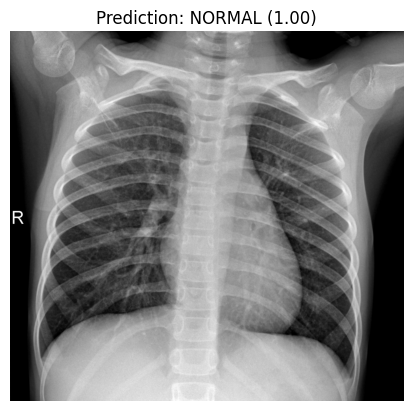


Prediction interrupted by user. Exiting.
Prediction script finished.


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /content/drive/MyDrive/data/src/predict.py

Configuration loaded successfully.
Using device: cuda
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda
Model loaded from models/ViT_pneumonia_best_model_10epochs.pth and ready for prediction.
Enter the path to the image (or type 'quit' to exit): /content/drive/MyDrive/data/train/PNEUMONIA/PNEUMONIA(1000).jpg

Prediction for 'PNEUMONIA(1000).jpg':
  Class: PNEUMONIA
  Probability: 0.9929



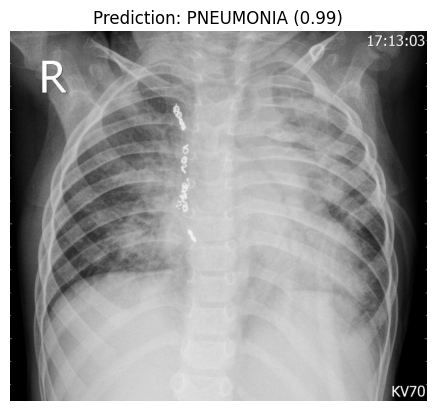


Prediction interrupted by user. Exiting.
Prediction script finished.


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /content/drive/MyDrive/data/src/predict.py

Configuration loaded successfully.
Using device: cuda
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda
Model loaded from models/ViT_pneumonia_best_model_10epochs.pth and ready for prediction.
Enter the path to the image (or type 'quit' to exit): /content/drive/MyDrive/data/train/NORMAL/IM-0156-0001.jpeg

Prediction for 'IM-0156-0001.jpeg':
  Class: NORMAL
  Probability: 0.9920



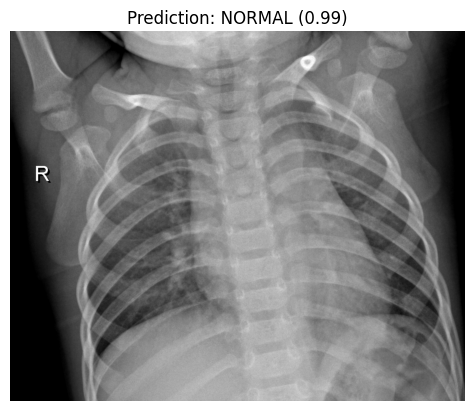


Prediction interrupted by user. Exiting.
Prediction script finished.


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /content/drive/MyDrive/data/src/predict.py

Configuration loaded successfully.
Using device: cuda
Attempting to load model from: models/ViT_pneumonia_best_model_10epochs.pth
Initialized ViTForImageClassification with backbone: google/vit-base-patch16-224-in21k
Number of classes: 2, Classifier Dropout: 0.1
Model loaded successfully from models/ViT_pneumonia_best_model_10epochs.pth and moved to cuda
Model loaded from models/ViT_pneumonia_best_model_10epochs.pth and ready for prediction.
Enter the path to the image (or type 'quit' to exit): /content/drive/MyDrive/data/train/PNEUMONIA/PNEUMONIA(104).jpg

Prediction for 'PNEUMONIA(104).jpg':
  Class: PNEUMONIA
  Probability: 0.9945



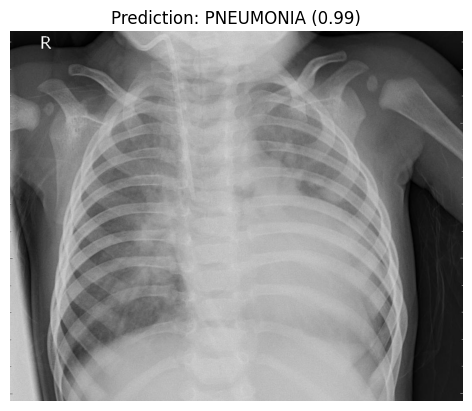

Enter the path to the image (or type 'quit' to exit): quit
Prediction script finished.


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /content/drive/MyDrive/data/src/predict.py